# Semantic Search — Data Visualization
Exploratory analysis of the arXiv CS dataset.  
Change `SAMPLE_SIZE` to load more rows if you have the full dataset ready.

## 0. Setup

In [4]:
%pip install -q matplotlib seaborn wordcloud

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import ast
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Adjust this path ──────────────────────────────────────────────
RAW_FILE = r'C:\Users\OLALERE\Desktop\Semantic search\data\raw\arxiv-metadata-oai-snapshot.jsonl'  # raw JSON file
PROCESSED_FILE = r'C:\Users\OLALERE\Desktop\Semantic search\data\processed\projects.csv'           # processed CSV (if ready)
SAMPLE_SIZE = 50000  # rows to read from raw JSON for exploration
# ──────────────────────────────────────────────────────────────────

print('Libraries loaded.')

Note: you may need to restart the kernel to use updated packages.
Libraries loaded.


## 1. Load Data

In [5]:
import os

if os.path.exists(PROCESSED_FILE):
    print(f'Loading processed file: {PROCESSED_FILE}')
    df_raw = pd.read_csv(PROCESSED_FILE, low_memory=False)
    IS_PROCESSED = True
else:
    print(f'Processed file not found — loading {SAMPLE_SIZE} rows from raw JSON...')
    if os.path.exists(PROCESSED_FILE):
        print(f'Loading processed file: {PROCESSED_FILE}')
        df_raw = pd.read_csv(PROCESSED_FILE, low_memory=False)
        IS_PROCESSED = True
    else:
        if not os.path.exists(RAW_FILE):
            raise FileNotFoundError(
                f'Raw file not found: {RAW_FILE}. '
                'Please download the dataset or update RAW_FILE to the correct path.'
            )

        print(f'Processed file not found — loading {SAMPLE_SIZE} rows from raw JSON...')
        df_raw = pd.read_json(RAW_FILE, lines=True, nrows=SAMPLE_SIZE)
        # Filter CS only
        df_raw = df_raw[df_raw['categories'].astype(str).str.contains(r'\bcs\.', regex=True, na=False)]
        IS_PROCESSED = False

    print(f'Shape : {df_raw.shape}')
    print(f'Columns: {df_raw.columns.tolist()}')
    df_raw.head(3)
    # Filter CS only
    df_raw = df_raw[df_raw['categories'].astype(str).str.contains(r'\bcs\.', regex=True, na=False)]
    IS_PROCESSED = False

print(f'Shape : {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Loading processed file: C:\Users\OLALERE\Desktop\Semantic search\data\processed\projects.csv
Shape : (892992, 5)
Columns: ['doc_id', 'title', 'abstract', 'keywords', 'category']


,doc_id,title,abstract,keywords,category
0,704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",math.CO cs.CG,math.CO cs.CG
1,704.0046,A limit relation for entropy and channel capac...,"In a quantum mechanical model, Diosi, Feldma...",quant-ph cs.IT math.IT,quant-ph cs.IT math.IT
2,704.0047,Intelligent location of simultaneously active ...,The intelligent acoustic emission locator is...,cs.NE cs.AI,cs.NE cs.AI


## 2. Data Cleaning & Feature Engineering

In [7]:
df = df_raw.copy()


# ── Abstract length ───────────────────────────────────────────────
abstract_col = 'abstract' if 'abstract' in df.columns else None
if abstract_col:
    df['abstract_len'] = df['abstract'].astype(str).apply(lambda x: len(x.split()))

# ── Category list ─────────────────────────────────────────────────
df['cat_list'] = df['category'].astype(str).str.strip().str.split()
df['n_category'] = df['cat_list'].apply(len)
df['primary_cat'] = df['cat_list'].apply(lambda x: x[0] if x else None)

# ── Author count (from raw JSON only) ────────────────────────────
if 'authors_parsed' in df.columns:
    def count_authors(x):
        try:
            parsed = ast.literal_eval(x) if isinstance(x, str) else x
            return len(parsed) if isinstance(parsed, list) else None
        except:
            return None
    df['n_authors'] = df['authors_parsed'].apply(count_authors)

# ── Version count (from raw JSON only) ───────────────────────────
if 'versions' in df.columns:
    def count_versions(x):
        try:
            parsed = ast.literal_eval(x) if isinstance(x, str) else x
            return len(parsed) if isinstance(parsed, list) else None
        except:
            return None
    df['n_versions'] = df['versions'].apply(count_versions)

print('Feature engineering complete.')
df[['primary_cat', 'n_category', 'abstract_len']].describe()

Feature engineering complete.


,n_category,abstract_len
count,892992.000000,892992.000000
mean,2.020009,167.449926
std,1.025578,51.646191
min,1.000000,1.000000
25%,1.000000,133.000000
50%,2.000000,167.000000
75%,3.000000,201.000000
max,13.000000,588.000000


## 3. Top CS Subcategories

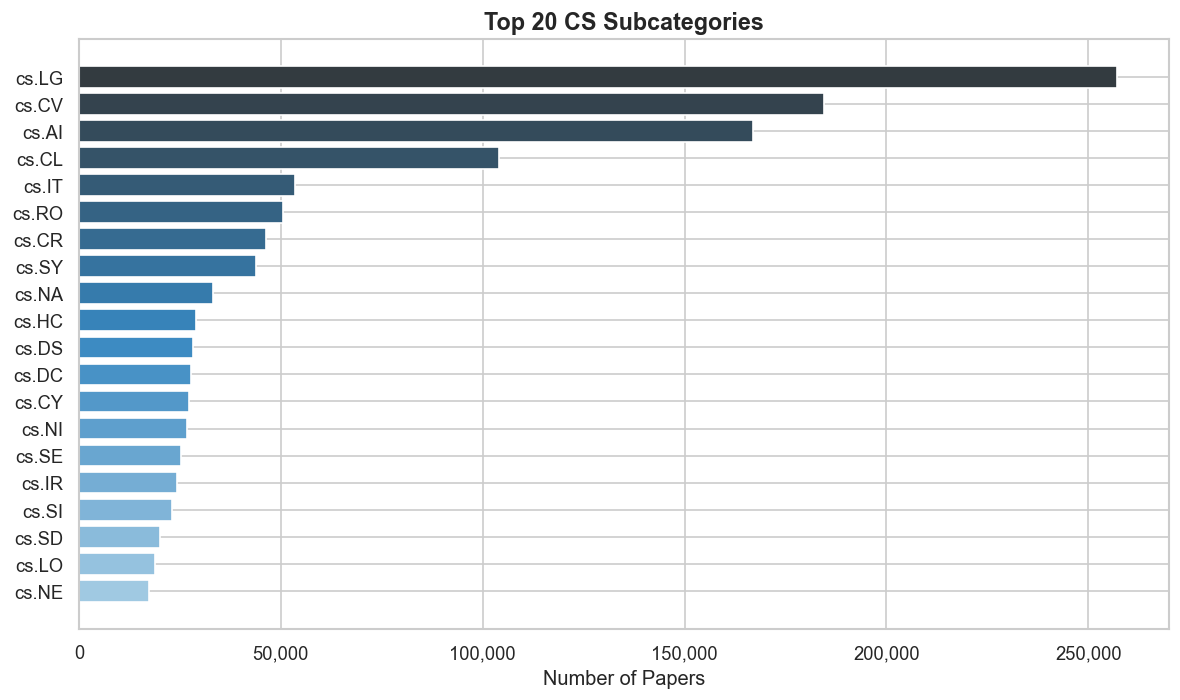

In [8]:
all_cats = [cat for cats in df['cat_list'] for cat in cats if cat.startswith('cs.')]
cat_counts = Counter(all_cats).most_common(20)
cat_df = pd.DataFrame(cat_counts, columns=['category', 'count'])

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_df['category'][::-1], cat_df['count'][::-1], color=sns.color_palette('Blues_d', 20))
ax.set_xlabel('Number of Papers')
ax.set_title('Top 20 CS Subcategories', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('top_cs_categories.png', bbox_inches='tight')
plt.show()

## 4. Papers Published Per Year

In [9]:
if 'year' in df.columns:
    year_counts = df['year'].value_counts().sort_index()
    year_counts = year_counts[(year_counts.index >= 2000) & (year_counts.index <= 2024)]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(year_counts.index, year_counts.values, alpha=0.3, color='steelblue')
    ax.plot(year_counts.index, year_counts.values, color='steelblue', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Papers')
    ax.set_title('CS Papers Published Per Year', fontsize=14, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('papers_per_year.png', bbox_inches='tight')
    plt.show()
else:
    print('update_date column not available in this dataset.')

update_date column not available in this dataset.


## 5. Abstract Length Distribution

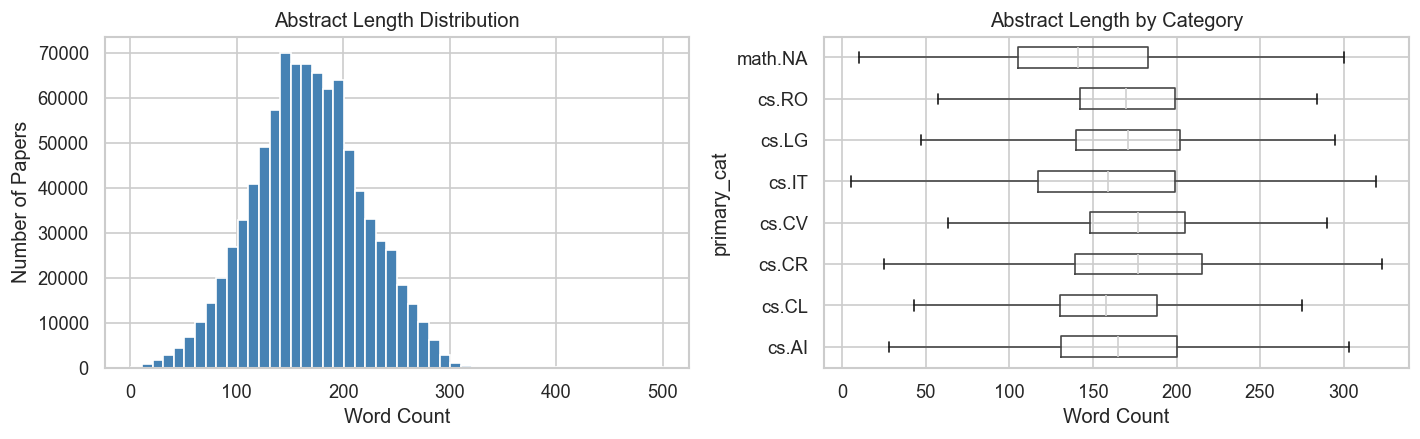

Mean abstract length : 167 words
Median abstract length: 167 words


In [10]:
if 'abstract_len' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axes[0].hist(df['abstract_len'].clip(0, 500), bins=50, color='steelblue', edgecolor='white')
    axes[0].set_xlabel('Word Count')
    axes[0].set_ylabel('Number of Papers')
    axes[0].set_title('Abstract Length Distribution')

    # Box plot by top 10 primary categories
    top_cats = df['primary_cat'].value_counts().head(8).index
    df_top = df[df['primary_cat'].isin(top_cats)]
    df_top.boxplot(column='abstract_len', by='primary_cat', ax=axes[1],
                   showfliers=False, vert=False)
    axes[1].set_xlabel('Word Count')
    axes[1].set_title('Abstract Length by Category')
    plt.suptitle('')

    plt.tight_layout()
    plt.savefig('abstract_length.png', bbox_inches='tight')
    plt.show()

    print(f"Mean abstract length : {df['abstract_len'].mean():.0f} words")
    print(f"Median abstract length: {df['abstract_len'].median():.0f} words")

## 6. Multi-Category Papers

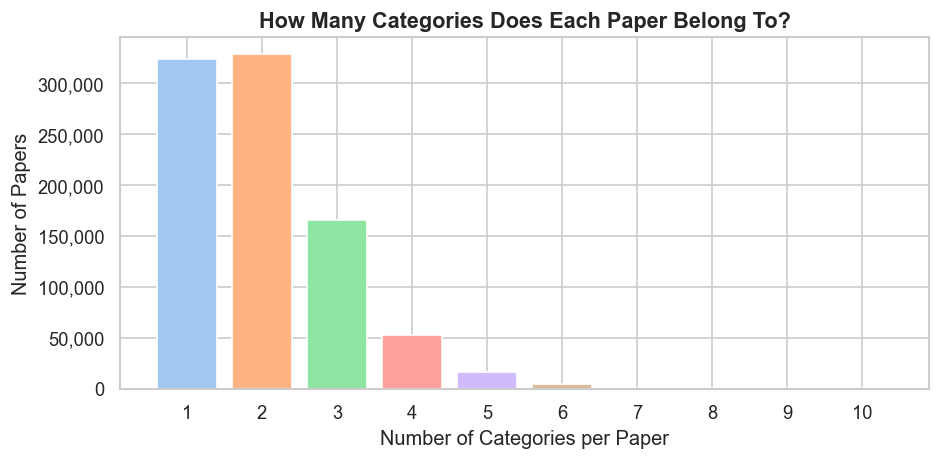

Single-category papers : 324,078
Multi-category papers  : 568,914


In [13]:
cat_dist = df['n_category'].value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cat_dist.index.astype(str), cat_dist.values, color=sns.color_palette('pastel'))
ax.set_xlabel('Number of Categories per Paper')
ax.set_ylabel('Number of Papers')
ax.set_title('How Many Categories Does Each Paper Belong To?', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('categories_per_paper.png', bbox_inches='tight')
plt.show()

print(f"Single-category papers : {(df['n_category'] == 1).sum():,}")
print(f"Multi-category papers  : {(df['n_category'] > 1).sum():,}")

## 7. Author Count Distribution

In [14]:
if 'n_authors' in df.columns:
    author_dist = df['n_authors'].dropna().clip(1, 15).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(author_dist.index.astype(int).astype(str), author_dist.values,
           color=sns.color_palette('Set2', len(author_dist)))
    ax.set_xlabel('Number of Authors')
    ax.set_ylabel('Number of Papers')
    ax.set_title('Author Count per Paper (capped at 15)', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('authors_per_paper.png', bbox_inches='tight')
    plt.show()

    print(f"Mean authors per paper  : {df['n_authors'].mean():.1f}")
    print(f"Median authors per paper: {df['n_authors'].median():.0f}")
else:
    print('authors_parsed not available — skipping author count chart.')

authors_parsed not available — skipping author count chart.


## 8. Revision Behaviour — Version Count

In [15]:
if 'n_versions' in df.columns:
    ver_dist = df['n_versions'].dropna().clip(1, 10).value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(ver_dist.index.astype(int).astype(str), ver_dist.values, color='coral', edgecolor='white')
    ax.set_xlabel('Number of Versions')
    ax.set_ylabel('Number of Papers')
    ax.set_title('How Many Times Are Papers Revised?', fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('versions_per_paper.png', bbox_inches='tight')
    plt.show()
else:
    print('versions column not available — skipping.')

versions column not available — skipping.


## 9. Title Word Cloud

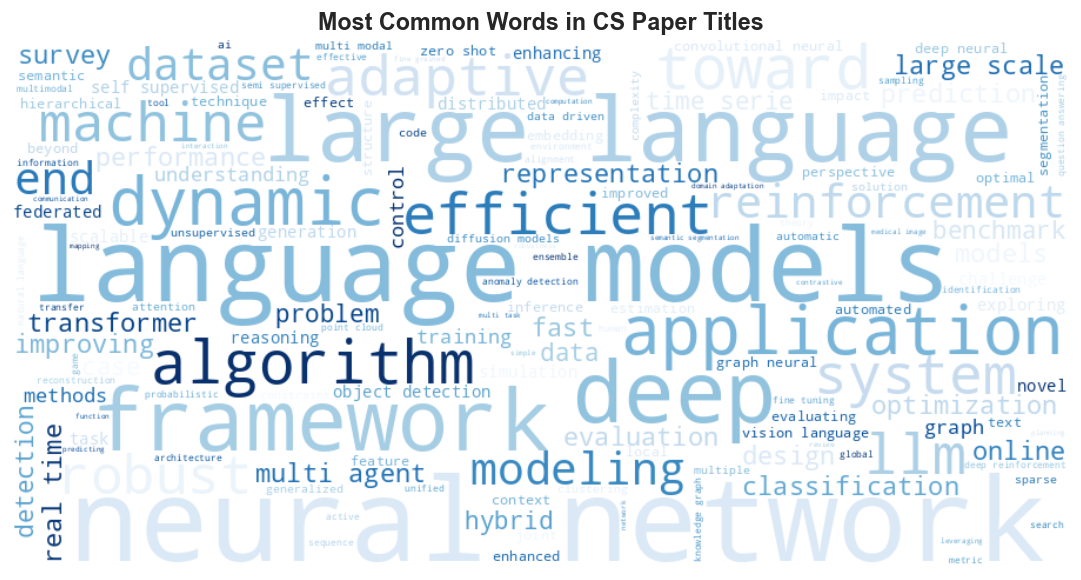

In [16]:
try:
    from wordcloud import WordCloud, STOPWORDS

    title_col = 'title' if 'title' in df.columns else None
    if title_col:
        extra_stops = {'using', 'based', 'via', 'new', 'approach', 'method',
                       'paper', 'study', 'analysis', 'learning', 'model'}
        stopwords = STOPWORDS.union(extra_stops)

        text = ' '.join(df['title'].dropna().astype(str).str.lower())
        wc = WordCloud(
            width=900, height=450,
            background_color='white',
            stopwords=stopwords,
            max_words=150,
            colormap='Blues'
        ).generate(text)

        fig, ax = plt.subplots(figsize=(12, 5))
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title('Most Common Words in CS Paper Titles', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('title_wordcloud.png', bbox_inches='tight')
        plt.show()
except ImportError:
    print('wordcloud not installed. Run: pip install wordcloud')

## 10. Category Growth Over Time

In [17]:
if 'year' in df.columns:
    TOP_N = 6
    top_primary = df['primary_cat'].value_counts().head(TOP_N).index.tolist()
    df_top = df[df['primary_cat'].isin(top_primary)]

    growth = df_top.groupby(['year', 'primary_cat']).size().reset_index(name='count')
    growth = growth[growth['year'].between(2010, 2024)]

    fig, ax = plt.subplots(figsize=(12, 5))
    for cat in top_primary:
        d = growth[growth['primary_cat'] == cat]
        ax.plot(d['year'], d['count'], marker='o', markersize=4, linewidth=2, label=cat)

    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Papers')
    ax.set_title(f'Growth of Top {TOP_N} CS Subcategories (2010–2024)', fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', framealpha=0.7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('category_growth.png', bbox_inches='tight')
    plt.show()
else:
    print('update_date not available — skipping growth chart.')

update_date not available — skipping growth chart.


## 11. Summary Statistics

In [19]:
print('=' * 45)
print('        DATASET SUMMARY')
print('=' * 45)
print(f"Total CS papers         : {len(df):,}")
print(f"Unique CS subcategories : {len(set(all_cats)):,}")

if 'year' in df.columns:
    print(f"Year range              : {int(df['year'].min())} – {int(df['year'].max())}")
if 'abstract_len' in df.columns:
    print(f"Avg abstract length     : {df['abstract_len'].mean():.0f} words")
if 'n_authors' in df.columns:
    print(f"Avg authors per paper   : {df['n_authors'].mean():.1f}")
if 'n_versions' in df.columns:
    print(f"Avg revisions per paper : {df['n_versions'].mean():.1f}")
print(f"Multi-category papers   : {(df['n_category'] > 1).mean()*100:.1f}%")
print('=' * 45)

        DATASET SUMMARY
Total CS papers         : 892,992
Unique CS subcategories : 40
Avg abstract length     : 167 words
Multi-category papers   : 63.7%
